In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans

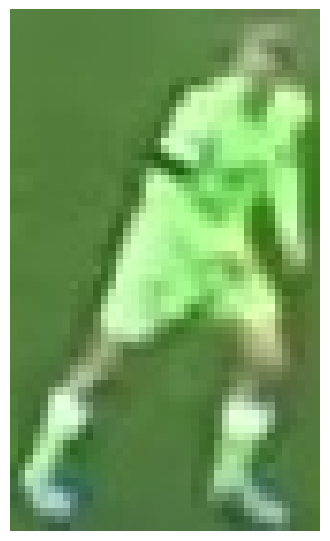

In [6]:

image_path = "../output/player_crop.jpg"

image = cv2.imread(image_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(4,8))
plt.imshow(image)
plt.axis("off")
plt.show()

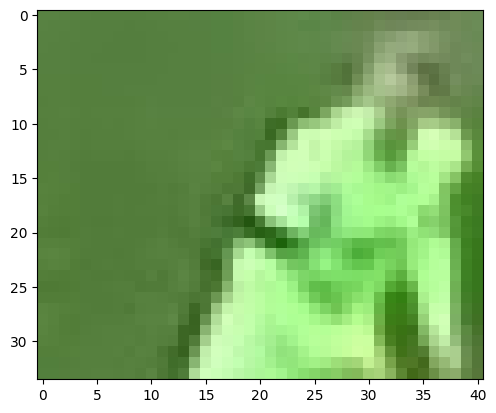

In [7]:
top_half_image=  image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

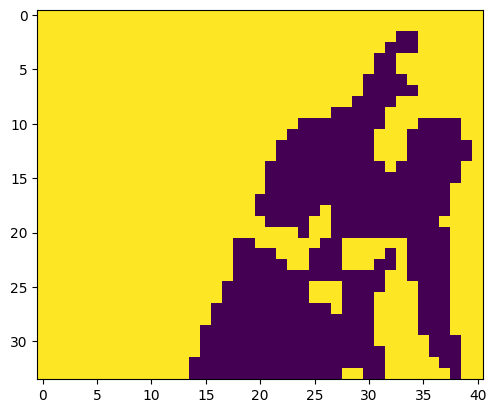

In [8]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the orginal image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [9]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

1


In [10]:
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [11]:
kmeans.cluster_centers_[player_cluster]

array([169.23341523, 233.10565111, 143.72235872])